In [2]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dotenv import load_dotenv
import datetime
import os
import mplfinance as mpf
import re
import utils

In [3]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [32]:
query_min = "SELECT * FROM gold.active_1min ORDER BY bar_date, bar_time"
query_5min = "SELECT * FROM gold.active_5min ORDER BY bar_date, bar_time"
query_15min = "SELECT * FROM gold.active_15min ORDER BY bar_date, bar_time"
df_min = pd.read_sql(query_min,engine)
df_5min = pd.read_sql(query_5min,engine)
df_15min = pd.read_sql(query_15min,engine)

Swing Table

In [27]:
def get_swings(df):
    highs = df['high'].to_numpy()
    lows = df['low'].to_numpy()
    closes = df['close'].to_numpy()
    opens = df['open'].to_numpy()
    times = df['bar_time'].to_numpy()
    dates = df['bar_date'].to_numpy()
    
    swings = []
    start = None
    end = None
    direction = None
    threshold = 0
    
    for i in range(1,len(closes)):
        cur_direction = None
        if (closes[i] > closes[i-1]):
            cur_direction = 'UP'
        elif closes[i] < closes[i-1]:
            cur_direction = 'DOWN'
        else:
            cur_direction = "NONE"
        if dates[i] != dates[i-1]:
            swing = [
                dates[start],
                times[start],
                times[end],
                (times[end].hour * 60 + times[end].minute) - (times[start].hour * 60 + times[start].minute),
                max(highs[start],highs[end]),
                opens[start],
                closes[end],
                min(lows[start],lows[end]),
                direction,
                profit,
                drawdown
            ]
            swings.append(swing)
            direction = None
            continue
        
        if direction == None:
            direction = cur_direction
            start = i-1
            end = i
        elif ((direction == cur_direction) or abs(closes[i]-closes[i-1])<threshold):
            end = i
        else:
            profit=0;
            drawdown=0;
            if direction == 'UP':
                profit = abs(highs[end] - opens[start])
                drawdown = abs(opens[start] - lows[start])
            elif direction == 'DOWN':
                profit = abs(lows[end] - opens[start])
                drawdown = abs(opens[start] - lows[start])
            swing = [
                dates[start],
                times[start],
                times[end],
                (times[end].hour * 60 + times[end].minute) - (times[start].hour * 60 + times[start].minute),
                max(highs[start],highs[end]),
                opens[start],
                closes[end],
                min(lows[start],lows[end]),
                direction,
                profit,
                drawdown
            ]
            swings.append(swing)
            direction = cur_direction
            start = i-1
            end = i
    swing_columns=['date','time_start','time_end','duration','high','open', 'close','low','direction','profit','drawdown']
    df_swings = pd.DataFrame(swings,columns=swing_columns)
    df_swings['bucket_30min'] = df_swings['time_start'].apply(
        lambda t: (datetime.datetime.min + datetime.timedelta(minutes=(t.hour*60+t.minute)//30*30)).time()
    )
    df_swings['bucket_15min'] = df_swings['time_start'].apply(
        lambda t: (datetime.datetime.min + datetime.timedelta(minutes=(t.hour*60+t.minute)//15*15)).time()
    )
    df_swings['bucket_5min'] = df_swings['time_start'].apply(
        lambda t: (datetime.datetime.min + datetime.timedelta(minutes=(t.hour*60+t.minute)//5*5)).time()
    )
    return df_swings

1 Minute Chart

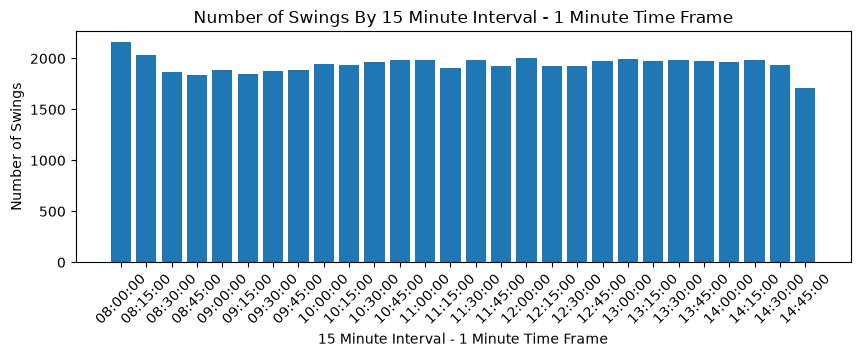

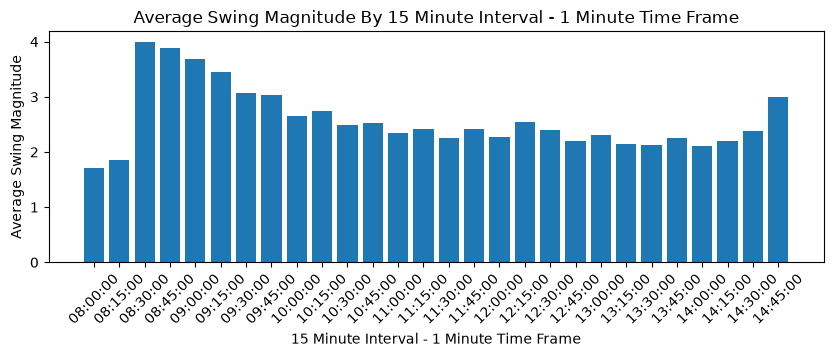

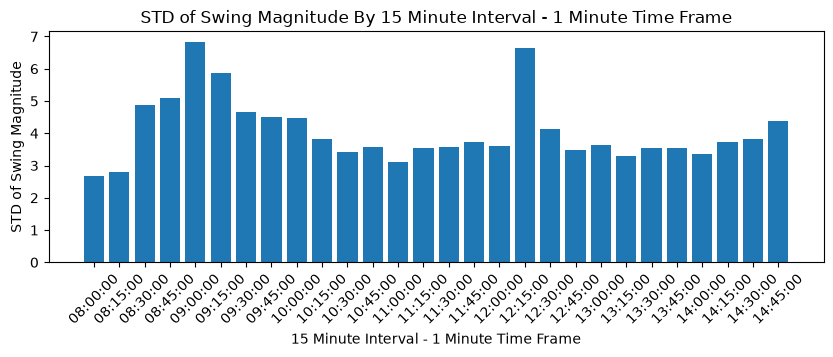

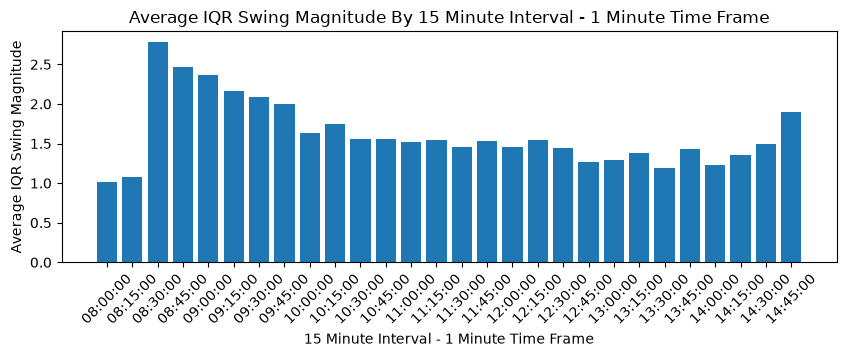

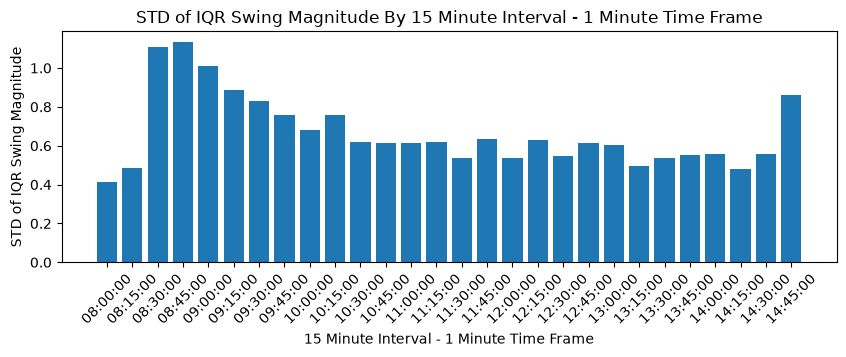

In [35]:
display_swings(df_min,'15','1')

5 Minute Chart

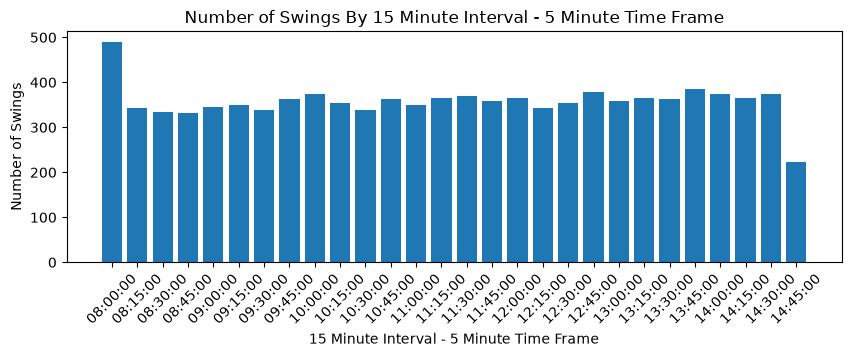

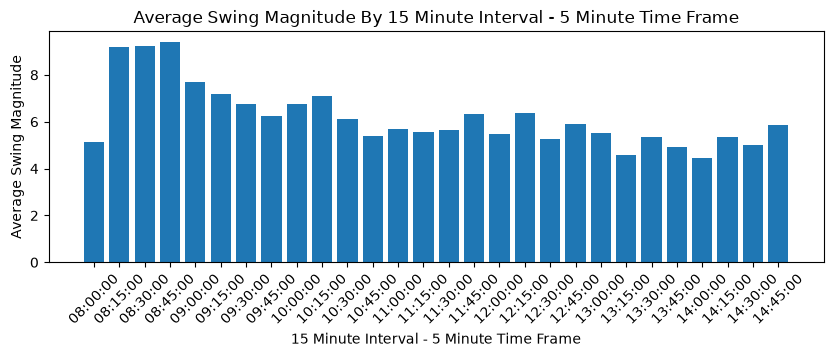

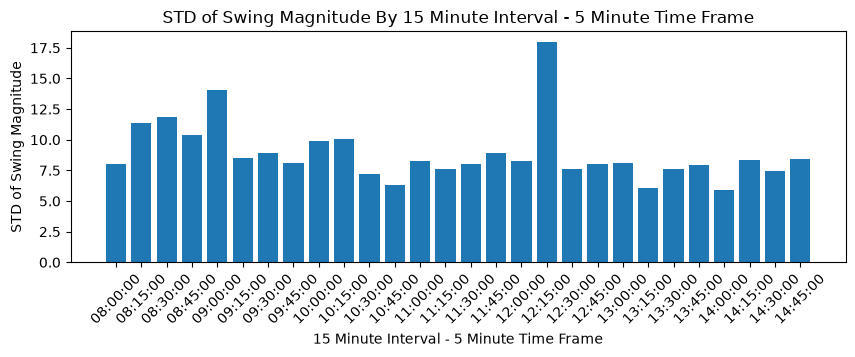

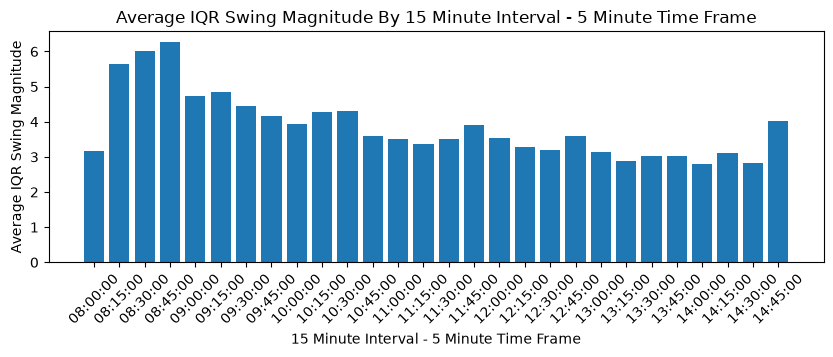

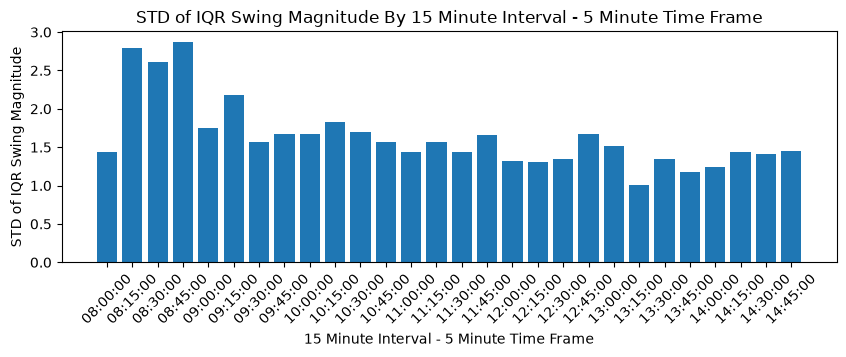

In [36]:
display_swings(df_5min,'15','5')

15 Minute Chart

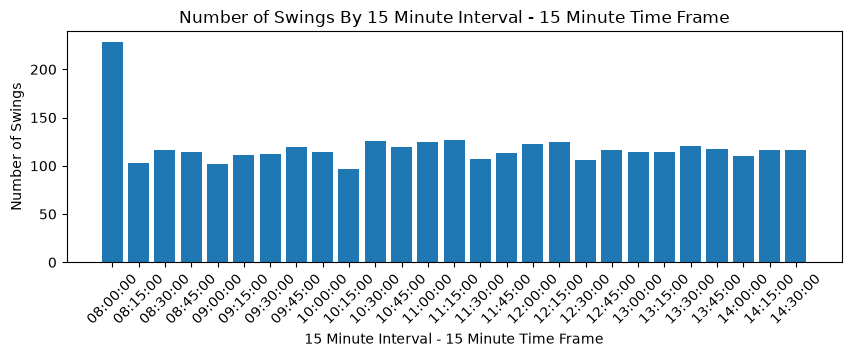

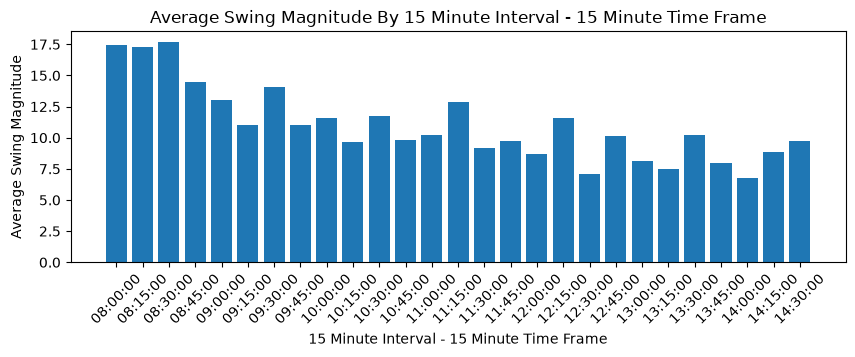

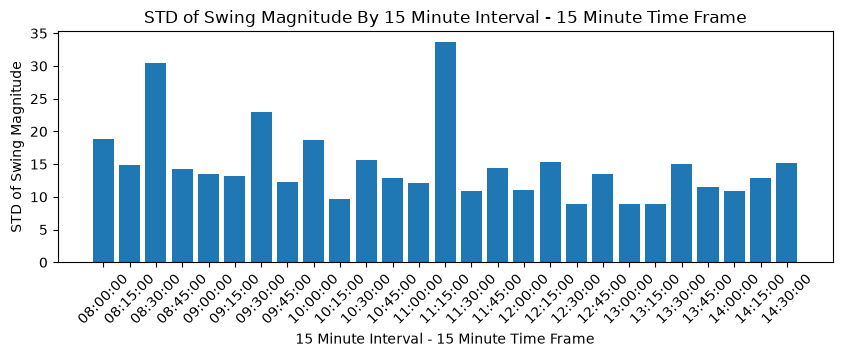

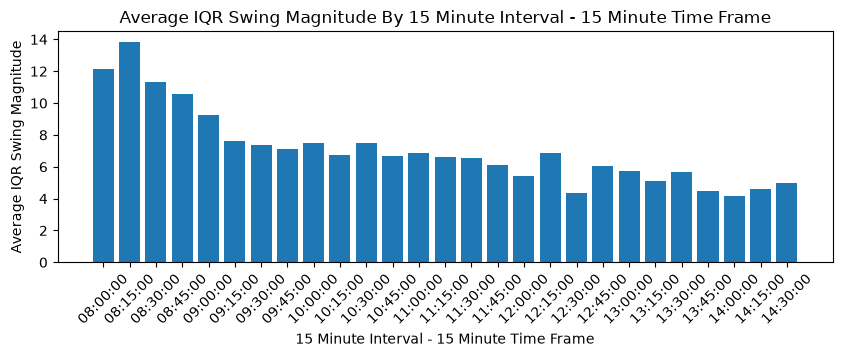

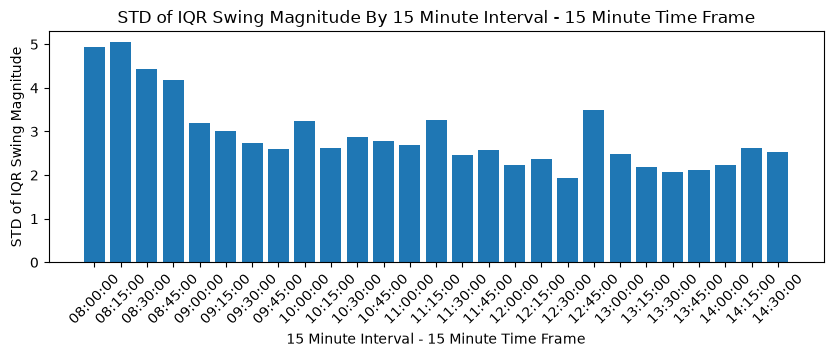

In [37]:
display_swings(df_15min,'15','15')